In [ ]:

!pip install transformers datasets torch

In [11]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

In [12]:
df = pd.read_csv('/content/processed_nlp_data.csv')
df.head()

,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,...,purchase_day,desc_length,subject_length,cleaned_description,cleaned_subject,final_description,final_subject,lemmatized_description,lemmatized_subject,final_text
0,32,Other,GoPro Hero,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,...,22,284,13,im having an issue with the productpurchased p...,product setup,im issue productpurchased please assist billin...,product setup,im issue productpurchased please assist billin...,product setup,product setup im issue productpurchased please...
1,42,Female,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,...,22,282,24,im having an issue with the productpurchased p...,peripheral compatibility,im issue productpurchased please assist need c...,peripheral compatibility,im issue productpurchased please assist need c...,peripheral compatibility,peripheral compatibility im issue productpurch...
2,48,Other,Dell XPS,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,...,14,275,15,im facing a problem with my productpurchased t...,network problem,im facing problem productpurchased productpurc...,network problem,im facing problem productpurchased productpurc...,network problem,network problem im facing problem productpurch...
3,27,Female,Microsoft Office,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,...,13,262,14,im having an issue with the productpurchased p...,account access,im issue productpurchased please assist proble...,account access,im issue productpurchased please assist proble...,account access,account access im issue productpurchased pleas...
4,67,Female,Autodesk AutoCAD,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,...,4,333,9,im having an issue with the productpurchased p...,data loss,im issue productpurchased please assist note s...,data loss,im issue productpurchased please assist note s...,data loss,data loss im issue productpurchased please ass...


In [13]:
X = df['final_text']
y = df['Ticket Type']

In [14]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [16]:
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [17]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [18]:
def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True)

In [19]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1694 [00:00<?, ? examples/s]

In [20]:
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

In [21]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    logging_dir='./logs'
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [33]:
trainer.train()

Step,Training Loss
500,1.610623
1000,1.605875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss
500,1.610623
1000,1.605875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1272, training_loss=1.6071705848166027, metrics={'train_runtime': 1057.3999, 'train_samples_per_second': 19.222, 'train_steps_per_second': 1.203, 'total_flos': 2692543923072000.0, 'train_loss': 1.6071705848166027, 'epoch': 3.0})

In [34]:
trainer.evaluate()

{'eval_loss': 1.6108744144439697,
 'eval_runtime': 29.3674,
 'eval_samples_per_second': 57.683,
 'eval_steps_per_second': 7.219,
 'epoch': 3.0}

In [35]:
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)

y_test = y_encoded[len(y_train):]

from sklearn.metrics import accuracy_score
print("DistilBERT Accuracy:", accuracy_score(y_test, y_pred))

DistilBERT Accuracy: 0.20425029515938606


In [36]:
from sklearn.metrics import classification_report, f1_score

# F1 Score (IMPORTANT)
f1 = f1_score(y_test, y_pred, average='macro')
print("F1 Score (Macro):", f1)

# Full Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

F1 Score (Macro): 0.17091337791866995

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.01      0.02       325
           1       0.20      0.25      0.22       323
           2       0.14      0.09      0.11       321
           3       0.23      0.44      0.30       366
           4       0.20      0.19      0.20       359

    accuracy                           0.20      1694
   macro avg       0.20      0.20      0.17      1694
weighted avg       0.20      0.20      0.17      1694



In [37]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset


# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv('/content/processed_nlp_data.csv')

# Combine subject + description (VERY IMPORTANT 🔥)
df['text'] = df['Ticket Subject'] + " " + df['Ticket Description']

X = df['text']
y = df['Ticket Type']


# ================================
# 3. LABEL ENCODING
# ================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# ================================
# 4. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# ================================
# 5. CREATE DATASETS
# ================================
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


# ================================
# 6. TOKENIZER
# ================================
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128   # 🔥 important
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


# ================================
# 7. LOAD MODEL
# ================================
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)


# ================================
# 8. TRAINING ARGUMENTS (OPTIMIZED 🔥)
# ================================
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,      # 🔥 key improvement
    logging_dir='./logs'
)


# ================================
# 9. TRAINER
# ================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


# ================================
# 10. TRAIN MODEL 🚀
# ================================
trainer.train()


# ================================
# 11. PREDICT
# ================================
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)


# ================================
# 12. EVALUATION (IMPORTANT)
# ================================
f1 = f1_score(y_test, y_pred, average='macro')
print("🔥 F1 Score (Macro):", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Map:   0%|          | 0/6775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1694 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,1.612441
1000,1.610260
1500,1.605441
2000,1.578304


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🔥 F1 Score (Macro): 0.17526026301378977

Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.14      0.15       327
           1       0.17      0.11      0.13       339
           2       0.15      0.07      0.10       328
           3       0.21      0.35      0.26       351
           4       0.21      0.27      0.23       349

    accuracy                           0.19      1694
   macro avg       0.18      0.19      0.18      1694
weighted avg       0.18      0.19      0.18      1694



In [38]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset


# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv('/content/processed_nlp_data.csv')

# 🔥 USE CLEAN TEXT (VERY IMPORTANT)
df['text'] = df['final_text']

X = df['text']
y = df['Ticket Type']


# ================================
# 3. LABEL ENCODING
# ================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# ================================
# 4. TRAIN TEST SPLIT (STRATIFIED)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# ================================
# 5. CREATE DATASETS
# ================================
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


# ================================
# 6. TOKENIZATION
# ================================
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


# ================================
# 7. LOAD MODEL
# ================================
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)


# ================================
# 8. TRAINING ARGUMENTS (FINAL 🔥)
# ================================
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=7,   # 🔥 IMPORTANT
    logging_dir='./logs'
)


# ================================
# 9. TRAINER
# ================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


# ================================
# 10. TRAIN MODEL 🚀
# ================================
trainer.train()


# ================================
# 11. PREDICTIONS
# ================================
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)


# ================================
# 12. EVALUATION (IMPORTANT)
# ================================
f1 = f1_score(y_test, y_pred, average='macro')
print("🔥 F1 Score (Macro):", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Map:   0%|          | 0/6775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1694 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,1.613094
1000,1.612209
1500,1.609174
2000,1.590969
2500,1.531814


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🔥 F1 Score (Macro): 0.18667964046475027

Classification Report:

              precision    recall  f1-score   support

           0       0.19      0.13      0.15       327
           1       0.17      0.22      0.19       339
           2       0.18      0.17      0.18       328
           3       0.19      0.21      0.20       351
           4       0.22      0.21      0.22       349

    accuracy                           0.19      1694
   macro avg       0.19      0.19      0.19      1694
weighted avg       0.19      0.19      0.19      1694



In [40]:
# ==============================
# 🔹 INSTALL
# ==============================
!pip install transformers datasets scikit-learn

# ==============================
# 🔹 IMPORTS
# ==============================
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from torch import nn

# ==============================
# 🔹 LOAD DATA
# ==============================
df = pd.read_csv('/content/processed_nlp_data.csv')

# 🔥 IMPORTANT TEXT FIX
df['text'] = df['Ticket Subject'].fillna('') + " " + df['Ticket Description'].fillna('')

# ==============================
# 🔹 FEATURES & LABELS
# ==============================
X = df['text']
y = df['Ticket Type']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==============================
# 🔹 DATASET FORMAT
# ==============================
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# ==============================
# 🔹 TOKENIZER
# ==============================
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# ==============================
# 🔹 MODEL
# ==============================
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)

# ==============================
# 🔹 CLASS WEIGHTS
# ==============================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# ==============================
# 🔹 CUSTOM TRAINER (FIXED)
# ==============================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):  # 🔥 FIX HERE
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ==============================
# 🔹 TRAINING SETTINGS
# ==============================
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=10,   # 🔥 important
    logging_dir='./logs'
)

# ==============================
# 🔹 TRAINER
# ==============================
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# ==============================
# 🔹 TRAIN
# ==============================
trainer.train()

# ==============================
# 🔹 EVALUATION
# ==============================
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)

f1 = f1_score(y_test, y_pred, average='macro')
print("🔥 F1 Score (Macro):", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Map:   0%|          | 0/6775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1694 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,1.613116
1000,1.612995
1500,1.612253
2000,1.608481
2500,1.606700
3000,1.552668
3500,1.508534
4000,1.346891
4500,1.207195
5000,1.078617


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🔥 F1 Score (Macro): 0.193382502550303

Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.21      0.19       327
           1       0.15      0.13      0.14       339
           2       0.19      0.19      0.19       328
           3       0.23      0.23      0.23       351
           4       0.23      0.21      0.22       349

    accuracy                           0.19      1694
   macro avg       0.19      0.19      0.19      1694
weighted avg       0.19      0.19      0.19      1694



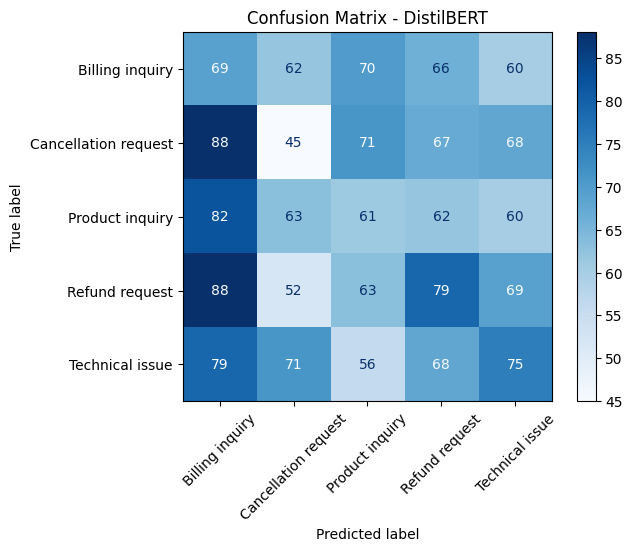

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix - DistilBERT")
plt.show()

In [42]:
!pip install shap